# Бетатронные частоты при выключенной ускоряющей системе

## Условие задачи

В накопителе с постоянным ведущим полем циркулирует протонный пучок с энергией $E$.
Ускоряющая ВЧ-система выключена, нелинейные поля отсутствуют, собственным полем пучка можно пренебречь.
Требуется определить, как меняются со временем бетатронные частоты частиц в пучке.

## Физический анализ

При выключенной ВЧ-системе потери энергии частиц не восполняются ускоряющим полем.
Основным механизмом потерь в вакууме накопителя служит синхротронное излучение, мощность которого пропорциональна четвёртой степени энергии, $P_\gamma \propto E^4$.
Для протонов излучение мало по сравнению с электронами из-за большой массы, но при энергиях порядка тераэлектронвольт оно становится заметным.
Дополнительный вклад дают ионизационные потери на остаточном газе.
В результате энергия и импульс частиц монотонно убывают.

Бетатронные частоты определяются жёсткостью магнитной структуры.
Сила квадрупольной линзы зависит от импульса частицы:
$$ k = \frac{e G}{p c}, $$
где $G$ — градиент магнитного поля, $p$ — импульс.
При уменьшении импульса фокусирующая сила растёт, и линзы действуют на частицы, потерявшие энергию, сильнее.
Зависимость бетатронной частоты от импульса характеризуется хроматизмом
$$ \xi = \frac{d\nu}{d(\Delta p / p)}, \qquad \Delta \nu = \xi \frac{\Delta p}{p}. $$
Натуральный хроматизм, создаваемый только квадруполями, отрицателен и по порядку величины равен $-\nu$: частицы с большим импульсом фокусируются слабее и имеют меньшую частоту колебаний.
При уменьшении импульса ($\Delta p < 0$) и отрицательном хроматизме изменение частоты положительно.

Таким образом, энергия протонов уменьшается со временем из-за радиационных потерь, фокусирующая система остаётся неизменной, и бетатронные частоты частиц растут.
Одновременно из-за уменьшения импульса в постоянном ведущем поле $B$ радиус орбиты $R = p / (e B)$ уменьшается, и пучок смещается внутрь кольца по дисперсионной орбите.
Импульсная апертура накопителя составляет доли процента или единицы процентов, поэтому пучок теряется на стенках камеры задолго до того, как изменение частоты станет большим.
Уже при $\Delta p / p \sim 1\%$ сдвиг частоты $\Delta \nu \sim 0.6$ проходит через резонансы низких порядков.

## Численный расчёт

Процесс моделируется для параметров, близких к LHC при энергии 7 ТэВ: радиус поворота в дипольных магнитах $\rho \approx 2.8$ км, периметр кольца $C \approx 26.7$ км, рабочая точка $\nu \approx 64.3$.
Потери энергии за оборот вычисляются по формуле
$$ U_0 = \frac{e^2}{3 \varepsilon_0} \frac{\gamma^4}{\rho}, $$
которая при 7 ТэВ даёт около 6.7 кэВ за оборот.
Энергия и частота обновляются по шагам времени в течение одного часа, а момент, когда относительное изменение импульса достигает 1 %, отмечен на графике.

Потери за оборот при 7 ТэВ: 6.66 кэВ
Частота обращения: 11.245 кГц


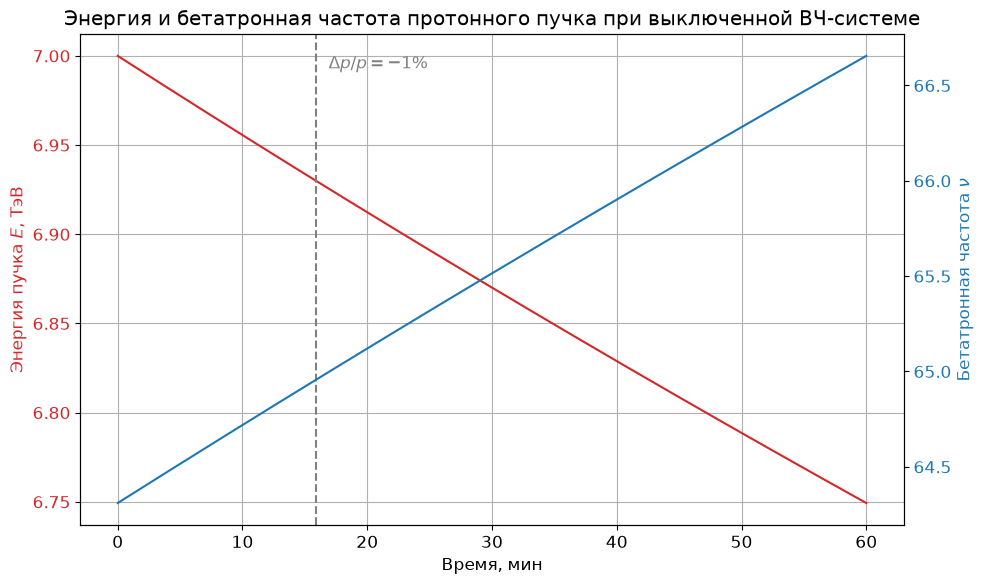

Импульсная апертура 1 % достигается через 15.9 мин, сдвиг частоты к этому моменту 0.647
Через час: энергия 6.749 ТэВ, сдвиг частоты 2.345


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Константы (СИ)
c = 299792458.0          # скорость света, м/с
m_p = 938.272e6          # масса протона, эВ
e_charge = 1.602e-19     # элементарный заряд, Кл
epsilon_0 = 8.854e-12    # электрическая постоянная, Ф/м

# Параметры накопителя (LHC)
E0 = 7.0e12              # начальная энергия, эВ
rho = 2804.0             # радиус поворота в дипольных магнитах, м
C_ring = 26659.0         # периметр кольца, м
nu_0 = 64.31             # рабочая точка
xi = -nu_0               # натуральный хроматизм d nu / d(dp/p), для FODO-структуры порядка -nu

def energy_loss_per_turn(E_eV):
    '''Потери на синхротронное излучение за оборот, эВ.'''
    gamma = E_eV / m_p
    U0_J = e_charge**2 / (3 * epsilon_0) * gamma**4 / rho
    return U0_J / e_charge

f_rev = c / C_ring
print(f"Потери за оборот при {E0/1e12:.0f} ТэВ: {energy_loss_per_turn(E0)/1e3:.2f} кэВ")
print(f"Частота обращения: {f_rev/1e3:.3f} кГц")

# Моделирование: один час с шагом одна секунда
t_max = 3600.0
dt = 1.0
time = np.arange(0, t_max + dt, dt)
E_vals = np.empty_like(time)
nu_vals = np.empty_like(time)

E = E0
nu = nu_0
for i in range(len(time)):
    E_vals[i] = E
    nu_vals[i] = nu
    dE = -energy_loss_per_turn(E) * f_rev * dt   # потери за шаг, эВ
    nu += xi * dE / E                           # для ультрарелятивистских частиц dp/p = dE/E
    E += dE

dp_over_p = (E_vals - E0) / E0
i_ap = np.argmax(dp_over_p < -0.01)             # момент достижения импульсной апертуры 1 %
t_ap = time[i_ap]

# Визуализация
fig, ax1 = plt.subplots()
ax1.set_xlabel('Время, мин')
ax1.set_ylabel('Энергия пучка $E$, ТэВ', color='tab:red')
ax1.plot(time / 60, E_vals / 1e12, color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel(r'Бетатронная частота $\nu$', color='tab:blue')
ax2.plot(time / 60, nu_vals, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax1.axvline(t_ap / 60, color='gray', linestyle='--')
ax1.text(t_ap / 60 + 1, E_vals[0] / 1e12, r'$\Delta p / p = -1\%$', color='gray', va='top')

plt.title('Энергия и бетатронная частота протонного пучка при выключенной ВЧ-системе')
fig.tight_layout()
plt.show()

print(f"Импульсная апертура 1 % достигается через {t_ap/60:.1f} мин, сдвиг частоты к этому моменту {nu_vals[i_ap] - nu_0:.3f}")
print(f"Через час: энергия {E_vals[-1]/1e12:.3f} ТэВ, сдвиг частоты {nu_vals[-1] - nu_0:.3f}")

## Итоги

При выключенной ВЧ-системе энергия протонов убывает из-за синхротронного излучения, а бетатронные частоты растут из-за отрицательного натурального хроматизма.
Для параметров LHC потери составляют около 6.7 кэВ за оборот, импульсная апертура в 1 % исчерпывается примерно за четверть часа, и к этому моменту частота сдвигается на величину порядка $0.6$, то есть пучок успевает пересечь несколько резонансов низких порядков.
Дальнейший рост частоты, показанный на графике, физически не реализуется, поскольку пучок теряется на стенках камеры.